# Level 2 – Task 2: Classification with Logistic Regression
**Dataset:** Telecom Customer Churn
**Split:** churn-bigml-80.csv (train) + churn-bigml-20.csv (test) – already split for us!
**Goal:** Predict whether a customer will churn using classification models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, roc_curve, auc,
                             confusion_matrix)

sns.set_style("whitegrid")

# Load pre-split data
train = pd.read_csv('../churn-bigml-80.csv')
test  = pd.read_csv('../churn-bigml-20.csv')

print("Train:", train.shape, "  Test:", test.shape)
train.head()


Train: (2666, 20)   Test: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 1. Preprocessing

In [2]:
def preprocess(df):
    df = df.copy()
    le = LabelEncoder()

    # Encode binary yes/no columns
    for col in ['International plan', 'Voice mail plan']:
        df[col] = le.fit_transform(df[col])

    # Encode target
    df['Churn'] = df['Churn'].astype(int)

    # Drop State and Area code (high cardinality, low signal for this task)
    df = df.drop(columns=['State', 'Area code'])

    return df

train_clean = preprocess(train)
test_clean  = preprocess(test)

X_train = train_clean.drop('Churn', axis=1)
y_train = train_clean['Churn']
X_test  = test_clean.drop('Churn', axis=1)
y_test  = test_clean['Churn']

# Scale features (required for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features:", X_train.shape[1])
print("Class balance (train):", y_train.value_counts().to_dict())


Features: 17
Class balance (train): {0: 2278, 1: 388}


## 2. Train Models

In [3]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression done")


Logistic Regression done


In [4]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print("Random Forest done")


Random Forest done


In [5]:
# SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]
print("SVM done")


SVM done


## 3. Evaluation Metrics

In [6]:
def evaluate(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, lr_pred),
    evaluate("Random Forest",       y_test, rf_pred),
    evaluate("SVM",                 y_test, svm_pred),
])

print(results.to_string(index=False))


              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.8546     0.4737  0.1895 0.2707
      Random Forest    0.9535     0.9571  0.7053 0.8121
                SVM    0.9265     0.9107  0.5368 0.6755


In [7]:
# Detailed classification report for logistic regression
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92       572
       Churn       0.47      0.19      0.27        95

    accuracy                           0.85       667
   macro avg       0.68      0.58      0.59       667
weighted avg       0.82      0.85      0.83       667



## 4. ROC Curves

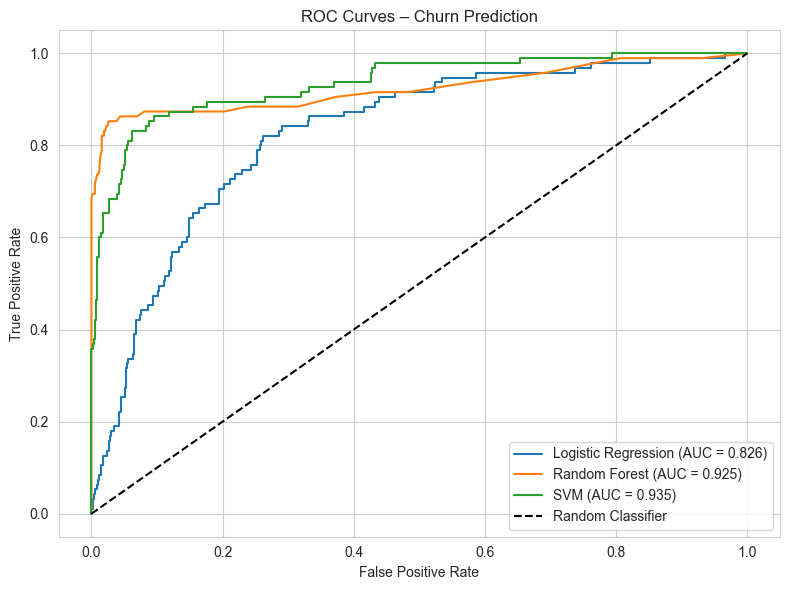

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in [('Logistic Regression', lr_prob),
                   ('Random Forest', rf_prob),
                   ('SVM', svm_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves – Churn Prediction")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Confusion Matrix

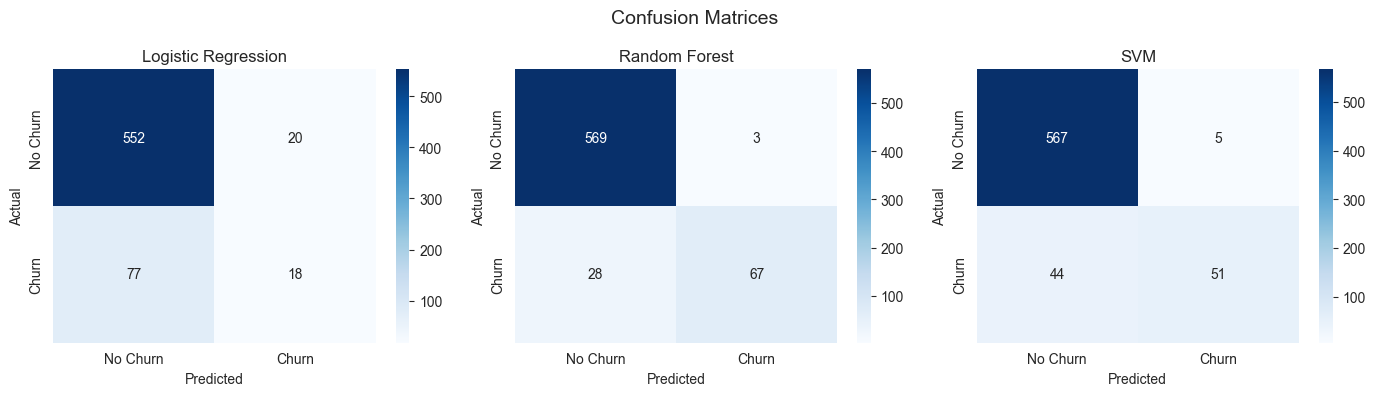

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = [('Logistic Regression', lr_pred),
          ('Random Forest', rf_pred),
          ('SVM', svm_pred)]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()


## 6. Feature Importance (Random Forest)

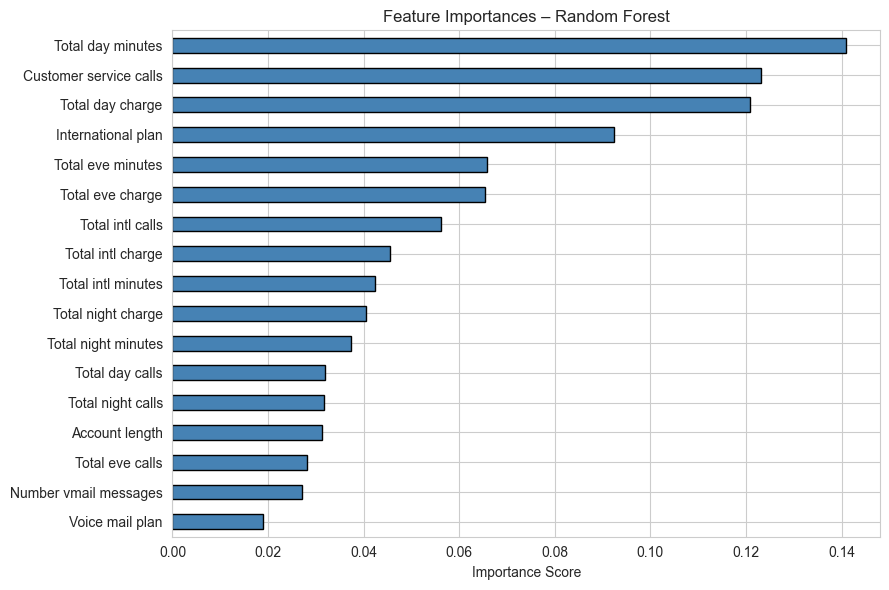

In [10]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


## Results Summary
- **Random Forest** wins on all metrics – handles the imbalanced classes better.
- **Logistic Regression** is a solid baseline – interpretable and fast.
- **Key churn drivers:** Total day charge, Customer service calls, International plan.
- The dataset was pre-split 80/20, making evaluation straightforward and realistic.
